# Import Libraries

In [1]:
# Import Neccessary libraries
import os
import yaml
import warnings
warnings.filterwarnings('ignore')
from typing import List, Dict

# Pandas packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn packages
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, 
                            precision_recall_curve,
                            recall_score, 
                            classification_report)

# Tensorflow Packages
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (ModelCheckpoint, 
                                        EarlyStopping)
from tensorflow.keras.optimizers import Adam

In [2]:
with open("config.yaml", 'r') as file:
    config = yaml.safe_load(file)

config

{'Inputs': {'input_csv_filepath': './data/creditcard.csv'},
 'Outputs': {'output_model_path': './artifacts/autoencoder_model.keras'}}

# Import and Check Data

- The data contains 284,807 European credit card transactions that occured over two days with 492 fradulent transactions. Everything except time and Amount rest all fields have been reduced to Principle Component Analysis(PCA) for privary concerns 

- Fields V1- V28 generated by PCA

In [3]:
data = pd.read_csv(config["Inputs"]["input_csv_filepath"])
print("Shape of the Input Dataset: ",data.shape)
print("No. of Columns:", data.shape[1])
print("No. of records:", data.shape[0])

Shape of the Input Dataset:  (284807, 31)
No. of Columns: 31
No. of records: 284807


In [4]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Target - Fradulent / Not Fradulent

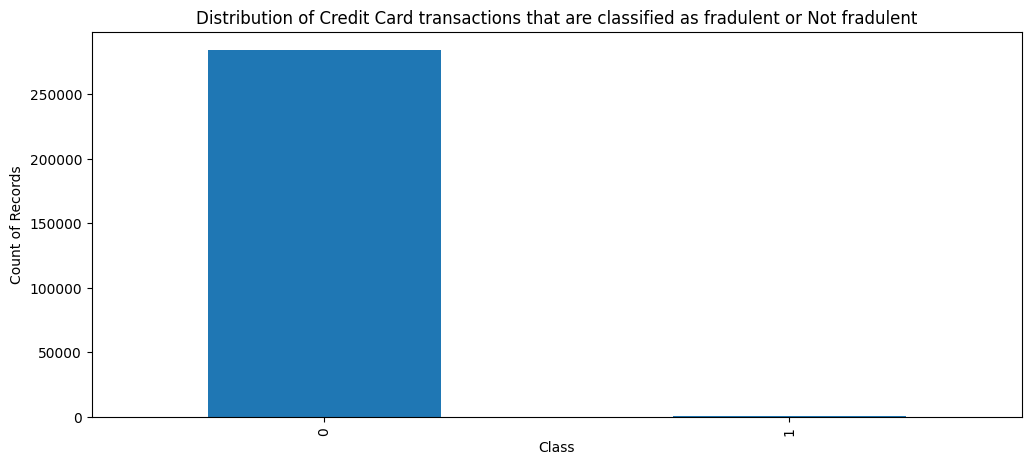

In [5]:
(data["Class"].value_counts() 
            .plot(kind = 'bar', 
                  figsize = (12, 5)))
plt.title("Distribution of Credit Card transactions that are classified as fradulent or Not fradulent")
plt.ylabel("Count of Records")
plt.show()

In [6]:
data["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

#### Check if there are any nulls

In [7]:
print("Are there any null records present in the dataset:", data.isnull().any().any())

Are there any null records present in the dataset: False


# Train Test Split

Since we want the model to learn and fit on normal data, we only use the 'not fradulent cases' only. This is to ensure that when an abnormal input is given to the model, its reconstruction error will be higher than that of a normal input. For testing of the model, samples from both the classes will be used.

In [12]:
X_train, X_test = train_test_split(data, train_size = 0.70, random_state = 42)

# Apply Standard Scaler on X_train
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_train.iloc[:, :-1])

# Transform X_train
X_train.iloc[:, :-1] = sc.transform(X_train.iloc[:, :-1])

# As said, in training set we have only "not fradulent cases"
X_train = X_train[X_train["Class"]==0]
X_train.drop("Class", axis = 1, inplace = True) # Dropping the target Variable

# Again Split the Test Dataset into Test and Validation
X = X_test.drop("Class", axis = 1)
y = X_test['Class']

X_val, X_test, y_val, y_test = train_test_split(X, y, train_size = 0.50, random_state = 42)

# Transform X_val, X_test
X_val = sc.transform(X_val)
X_test = sc.transform(X_test)

print(f"Shape of Training Dataset: {X_train.shape}")
print("*"*200)
print(f"Shape of Validation Dataset: {X_val.shape}")
print(f"Shape of Test Dataset: {X_test.shape}")
print(f"Shape of Validation (target) Dataset: {y_val.shape}")
print(f"Shape of Test (target) Dataset: {y_test.shape}")


Shape of Training Dataset: (199008, 30)
********************************************************************************************************************************************************************************************************
Shape of Validation Dataset: (42721, 30)
Shape of Test Dataset: (42722, 30)
Shape of Validation (target) Dataset: (42721,)
Shape of Test (target) Dataset: (42722,)


# Modelling

#### AutoEncoder Architecture


1. Encoder 

    The encoder typically consists of one or more full connected layers that transforms the input data into a lower-dimensional representation. The number of nodes present in the hidden layer is typically smaller than the input and output layers, which forces the network to learn a compressed representation of the input data. The activation function used in the encoder can be any non-linear function, such as sigmoid or a rectified linear unit (ReLU), which allows the network to capture non-linear relationship in the input data.


2. Decoder

    The decoder is typically a mirror image of the encoder, with one or more fully connected layers that transform the compressed representation back into the original input space. The output layer of decorder having the same number of nodes as the input layer, so that the decoder can produce a reconstruction of the input data. The activation function used in the decoder is same as the one used in encoder. 

In [13]:
INPUT_SHAPE = X_train.shape[1] 
OUTPUT_SHAPE = INPUT_SHAPE

In [14]:
# Using Keras Functional API
input_layer = Input(shape = (INPUT_SHAPE, ))
dense_encoder_layer1 = Dense(28, activation = "relu")(input_layer)
dense_encoder_layer2 = Dense(14, activation = "relu")(dense_encoder_layer1)
dense_encoder_layer3 = Dense(7, activation = "relu")(dense_encoder_layer2)

lower_latent_space = Dense(2, activation = "relu")(dense_encoder_layer3)

dense_decoder_layer1 = Dense(7, activation = "relu")(lower_latent_space)
dense_decoder_layer2 = Dense(14, activation = "relu")(dense_decoder_layer1)
dense_decoder_layer3 = Dense(28, activation = "relu")(dense_decoder_layer2)

output_layer  = Dense(OUTPUT_SHAPE, activation = "relu")(dense_decoder_layer3)

autoencoder_model = Model(input_layer, output_layer)
print(autoencoder_model.summary())

2025-06-09 00:54:30.790219: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-06-09 00:54:30.790353: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-06-09 00:54:30.790366: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
I0000 00:00:1749448470.790473 2725116 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1749448470.790565 2725116 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 28)             │           868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 28)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │           870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,818 (11.01 KB)

 Trainable params: 2,818 (11.01 KB)

 Non-trainable params: 0 (0.00 B)

None


#### Model Callbacks


- ModelCheckpoint : ModelCheckpoint callback is used in conjunction with training using model.fit() to save a model or weight at some interval, so the model or weights can be loaded later to continue the training from the state saved


In [15]:
model_filepath = "./artifacts/autoencoder.weights.h5"

# Model Checkpoint
model_checkpoint_callback = ModelCheckpoint(
    model_filepath, 
    save_weights_only = True, 
    save_best_only = True, 
    mode = 'max',
    monitor = "val_accuracy",
    verbose = 1
)

# Model Callbacks
model_earlystopping_callback = EarlyStopping(
    monitor = 'val_loss',
    min_delta = 0,
    patience = 5, 
    verbose = 1,
    restore_best_weights = True
)

callbacks = [model_checkpoint_callback, model_earlystopping_callback]

#### Compile

In [16]:
autoencoder_model.compile(loss = "mae", 
                          optimizer = Adam())

#### Fit Model

In [18]:
autoencoder_model.fit(X_train, X_train, 
                      epochs = 25, batch_size = 64, 
                      validation_data = (X_val, X_val), 
                      callbacks = callbacks, shuffle = True)

Epoch 1/25


2025-06-09 00:55:15.008527: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


3110/3110 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - loss: 2340721.2500 - val_loss: 251504320.0000
Epoch 2/25
3110/3110 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 1107050496.0000 - val_loss: 11838926848.0000
Epoch 3/25
3110/3110 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 21786472448.0000 - val_loss: 79740239872.0000
Epoch 4/25
3110/3110 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - loss: 142432911360.0000 - val_loss: 440361484288.0000
Epoch 5/25
3110/3110 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - loss: 573638246400.0000 - val_loss: 1211969699840.0000
Epoch 6/25
3110/3110 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 1692813885440.0000 - val_loss: 3289572704256.0000
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


#### Save and Load the Model

In [22]:
autoencoder_model.save(config["Outputs"]["output_model_path"])

# Results 

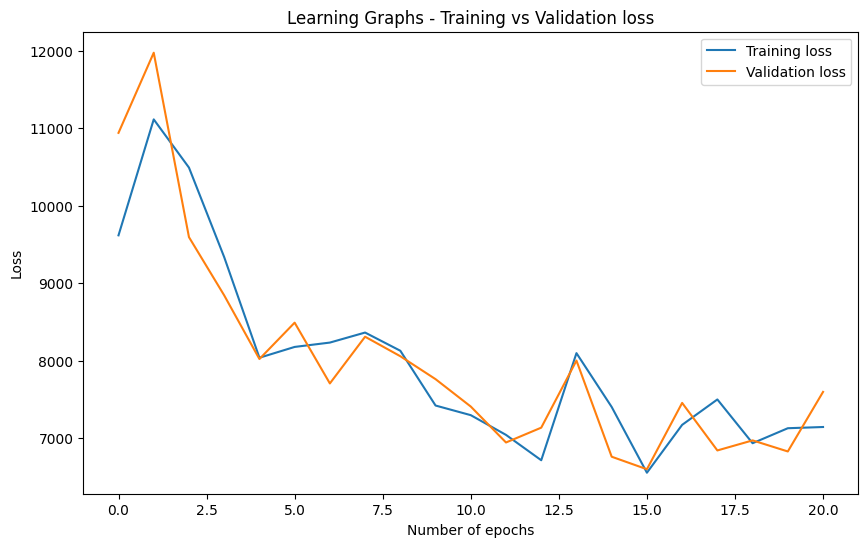

In [17]:
plt.figure(figsize = (10, 6))
plt.plot(autoencoder_model.history.history["loss"], label = "Training loss")
plt.plot(autoencoder_model.history.history["val_loss"], label = "Validation loss")
plt.title("Learning Graphs - Training vs Validation loss")
plt.xlabel("Number of epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Reconstruction

In [23]:
reconstruction = autoencoder_model.predict(X_test.to_numpy(), verbose = 0)

In [28]:
from sklearn.metrics import mean_absolute_error

In [29]:
mean_absolute_error(reconstruction, X_test.to_numpy())

6583.076033516438